<a href="https://colab.research.google.com/github/fabianoborgesbsb/APC_study/blob/main/Mobilidade_Lattes_OpenAlex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autorias brasileiras

Cruzamento OpenAlex e Lattes

In [ ]:
%%bigquery --project=multiobs

CREATE OR REPLACE TABLE projectdb_mobility_br.authorships_br AS (
  SELECT a.work_id, a.author_id, a.author_order, a.institution_id, b.IDLattes
  FROM publicdb_openalex_2026_01_rm.works_authorships_affiliations AS a
  JOIN projectdb_lattes.match_researchers_lattes_openalex AS b
  ON a.author_id = b.author_id
)

Executing query with job ID: 4058549e-3fce-4d46-81ff-61a78118ebbe
Query executing: 0.40s


ERROR:
 403 Access Denied: Table multiobs:projectdb_lattes.match_researchers_lattes_openalex: User does not have permission to query table multiobs:projectdb_lattes.match_researchers_lattes_openalex, or perhaps it does not exist.; reason: accessDenied, message: Access Denied: Table multiobs:projectdb_lattes.match_researchers_lattes_openalex: User does not have permission to query table multiobs:projectdb_lattes.match_researchers_lattes_openalex, or perhaps it does not exist.

Location: US
Job ID: 4058549e-3fce-4d46-81ff-61a78118ebbe



# Autorias por ano de publicação

In [ ]:
%%bigquery --project=multiobs

CREATE OR REPLACE TABLE projectdb_mobility_br.authorships_br_year AS (
  SELECT a.*, b.publication_year
  FROM projectdb_mobility_br.authorships_br AS a
  JOIN publicdb_openalex_2026_01_rm.works AS b
  ON a.work_id = b.id
)

Query is running:   0%|          |

""


# Autorias por ano com as instituições

In [ ]:
%%bigquery --project=multiobs

CREATE OR REPLACE TABLE projectdb_mobility_br.institutions_persons AS (
  SELECT DISTINCT a.IDLattes, a.author_id, a.institution_id
  FROM projectdb_mobility_br.authorships_br_year AS a
)

Query is running:   0%|          |

""


# Maior e menor ano de coincidência autor-instituição

In [ ]:
%%bigquery --project=multiobs

# Em princípio, para cada IDLattes, existe um único author_id, mas conforme
# discutido no artigo de cruzamento, pode haver duplicidades e mesclas.
# Agrupamento com ambos mantém todos os casos separados.
CREATE OR REPLACE TABLE projectdb_mobility_br.institutions_span_years AS (
  SELECT a.IDLattes, a.author_id,
    b.PrimeiraGrandeArea AS area,
    a.institution_id,
    MAX(a.publication_year) AS max_year,
    MIN(a.publication_year) AS min_year,
  FROM projectdb_mobility_br.authorships_br_year AS a
  JOIN `multiobs.projectdb_lattes_2025.Tabelaconsolidadacomgeneroetitulacao` AS b
  ON a.IDLattes = b.IDLattes
  GROUP BY a.IDLattes, a.author_id, b.PrimeiraGrandeArea, a.institution_id
)

Query is running:   0%|          |

""


In [ ]:
%%bigquery --project=multiobs

SELECT *
FROM projectdb_mobility_br.institutions_span_years

Query is running:   0%|          |

Downloading:   0%|          |

,IDLattes,author_id,area,institution_id,max_year,min_year
0,'3831029821856668,5079074458,None,147171140,<NA>,<NA>
1,'8357814595319758,5062629353,None,70768539,<NA>,<NA>
2,'8245539710153975,5015640408,None,174015415,1885,1885
3,'7946840063066238,5004855417,None,4210090421,1954,1954
4,'5262867296853603,5087949757,None,40347166,1955,1955
...,...,...,...,...,...,...
2263421,'7524671581334750,5004881573,OUTROS,4210103065,2025,2025
2263422,'7279933907794147,5088267338,OUTROS,124055696,2025,2025
2263423,'0333536290992282,5075460512,OUTROS,4210135534,2025,2025
2263424,'6276177400734590,5005209011,OUTROS,4210118630,2025,2025


# Mobilidade líquida entre os anos 1990 e 2020 (inclusive)

$M_i = E_i-S_i$

- $M_i$ - Mobilidade líquida no ano $i$
- $E_i$ - número de autores com primeira ocorrência no ano $i$
- $S_i$ - número de autores com última ocorrência no ano $i$

Cálculo para cada instituição

In [ ]:
%%bigquery df --project=multiobs

CREATE OR REPLACE TABLE projectdb_mobility_br.institutions_net_mobility AS (
  SELECT a.institution_id,
    a.input_year AS year,
    a.authors_in,
    b.authors_out,
    a.authors_in-b.authors_out AS net_mobility
  FROM (
    SELECT institution_id,
      min_year AS input_year,
      COUNT(DISTINCT(author_id)) AS authors_in
    FROM projectdb_mobility_br.institutions_span_years
    GROUP BY institution_id, min_year
  ) AS a
  JOIN (
    SELECT institution_id,
      max_year AS output_year,
      COUNT(DISTINCT(author_id)) AS authors_out
    FROM projectdb_mobility_br.institutions_span_years
    GROUP BY institution_id, max_year
  ) AS b
  ON a.institution_id = b.institution_id
  WHERE a.input_year = b.output_year AND a.institution_id != -1
    AND a.input_year <= 2020 AND a.input_year >= 1990
)

Query is running:   0%|          |

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Empty DataFrame


## Mobilidade por ano e por grande área

Mesma tabela acima de agregação de entradas e saídas mas divididas por grande área do Lattes

In [ ]:
%%bigquery --project=multiobs

CREATE OR REPLACE TABLE projectdb_mobility_br.institutions_net_mobility_area AS (
  SELECT a.institution_id,
    a.input_year AS year,
    a.area,
    a.authors_in,
    b.authors_out,
    a.authors_in-b.authors_out AS net_mobility
  FROM (
    SELECT institution_id,
      min_year AS input_year,
      area,
      COUNT(DISTINCT(author_id)) AS authors_in
    FROM projectdb_mobility_br.institutions_span_years
    GROUP BY institution_id, min_year, area
  ) AS a
  JOIN (
    SELECT institution_id,
      max_year AS output_year,
      area,
      COUNT(DISTINCT(author_id)) AS authors_out
    FROM projectdb_mobility_br.institutions_span_years
    GROUP BY institution_id, max_year, area
  ) AS b
  ON a.institution_id = b.institution_id
  WHERE a.input_year = b.output_year AND a.institution_id != -1
    AND a.input_year <= 2020 AND a.input_year >= 1990
    AND a.area = b.area
)

Query is running:   0%|          |

""


# Mobilidade líquida agregada para todos os anos por instituição

$ A = \sum_{i=1990}^{2020} M__i $

In [ ]:
%%bigquery --project=multiobs

CREATE OR REPLACE TABLE projectdb_mobility_br.institutions_net_mobility_all_years AS (
  SELECT institution_id,
    SUM(authors_in) AS authors_in,
    SUM(authors_out) AS authors_out,
    SUM(authors_in)-SUM(authors_out) AS net_mobility
  FROM projectdb_mobility_br.institutions_net_mobility
  GROUP BY institution_id
)


Query is running:   0%|          |

""


## Mobilidade líquida por anos por área

In [ ]:
%%bigquery  df--project=multiobs

CREATE OR REPLACE TABLE projectdb_mobility_br.institutions_net_mobility_all_years_area AS (
  SELECT institution_id,
    area,
    SUM(authors_in) AS authors_in,
    SUM(authors_out) AS authors_out,
    SUM(authors_in)-SUM(authors_out) AS net_mobility
  FROM projectdb_mobility_br.institutions_net_mobility_area
  GROUP BY institution_id, area
)

Query is running:   0%|          |

In [ ]:
# checagem
%%bigquery df --project=multiobs
SELECT * FROM projectdb_mobility_br.institutions_net_mobility_all_years_area


Query is running:   0%|          |

Downloading:   0%|          |

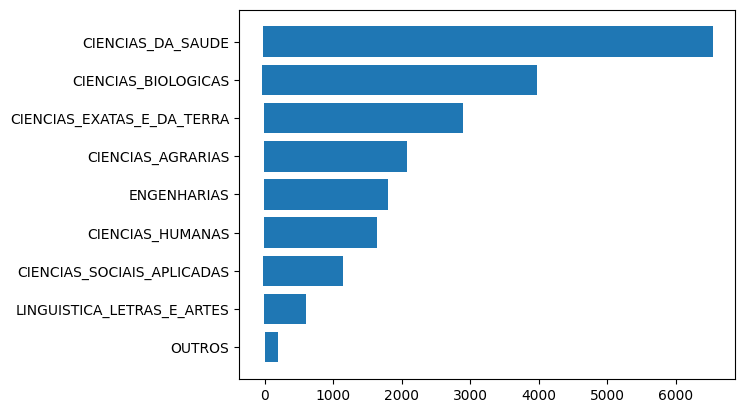

In [ ]:
import matplotlib.pyplot as plt
df_ordenado = df.sort_values(by='net_mobility', ascending=False)
plt.barh(y=df_ordenado['area'], width=df_ordenado['net_mobility'])
plt.gca().invert_yaxis()
plt.show()

In [ ]:
%%bigquery df_institutions--project=multiobs

CREATE OR REPLACE TABLE projectdb_mobility_br.institutions_net_mobility_all_years_areas_names AS (
  SELECT a.*, b.display_name, b.city, b.country
  FROM projectdb_mobility_br.institutions_net_mobility_all_years_area AS a
  JOIN publicdb_openalex_2026_01_rm.institutions AS b
  ON a.institution_id = b.id
)




Query is running:   0%|          |

In [ ]:
%%bigquery df_institutions --project=multiobs
SELECT * FROM projectdb_mobility_br.institutions_net_mobility_all_years_areas_names


Query is running:   0%|          |

Downloading:   0%|          |

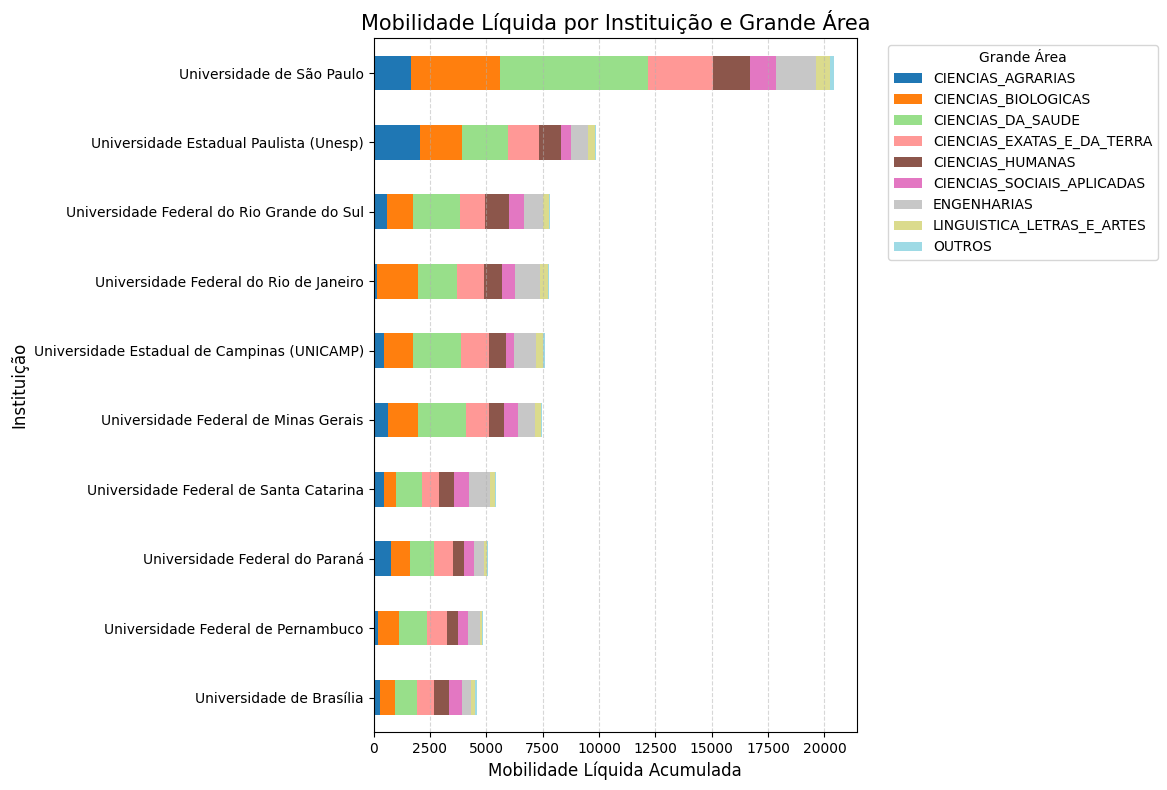

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Lista das universidades top 10
top_universities = [
    'Universidade de Brasília', 'Universidade Federal de Pernambuco',
    'Universidade Federal do Paraná', 'Universidade Federal de Minas Gerais', 'Universidade Federal de Santa Catarina',
    'Universidade Estadual de Campinas (UNICAMP)', 'Universidade Federal do Rio de Janeiro',
    'Universidade Federal do Rio Grande do Sul', 'Universidade Estadual Paulista (Unesp)',
    'Universidade de São Paulo'
]

# 2. Filtra
df_top = df_institutions[df_institutions['display_name'].isin(top_universities)]

# 3. Pivota dados
pivot_df = df_top.pivot_table(index='display_name', columns='area', values='net_mobility', aggfunc='sum').fillna(0)

# 4. Ordena instituições
pivot_df['total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by='total', ascending=True).drop(columns='total')

ax = pivot_df.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='tab20')
plt.title('Mobilidade Líquida por Instituição e Grande Área', fontsize=15)
plt.xlabel('Mobilidade Líquida Acumulada', fontsize=12)
plt.ylabel('Instituição', fontsize=12)
plt.legend(title='Grande Área', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Ordenado por instituição com cidade ($N$ maiores)

In [ ]:
%%bigquery --project=multiobs

CREATE OR REPLACE TABLE projectdb_mobility_br.institutions_net_mobility_all_years_names AS (
  SELECT a.*, b.display_name, b.city, b.country
  FROM projectdb_mobility_br.institutions_net_mobility_all_years AS a
  JOIN publicdb_openalex_2026_01_rm.institutions AS b
  ON a.institution_id = b.id
)

Query is running:   0%|          |

""


In [ ]:
%%bigquery --project=multiobs

CREATE OR REPLACE TABLE projectdb_mobility_br.institutions_net_mobility_all_years_areas_names AS (
  SELECT a.*, b.display_name, b.city, b.country
  FROM projectdb_mobility_br.institutions_net_mobility_all_years_area AS a
  JOIN publicdb_openalex_2026_01_rm.institutions AS b
  ON a.institution_id = b.id
)

Query is running:   0%|          |

""


In [ ]:
%%bigquery df --project=multiobs

SELECT *
FROM projectdb_mobility_br.institutions_net_mobility_all_years_areas_names
ORDER BY net_mobility DESC
LIMIT 10

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   institution_id  10 non-null     Int64 
 1   area            10 non-null     object
 2   authors_in      10 non-null     Int64 
 3   authors_out     10 non-null     Int64 
 4   net_mobility    10 non-null     Int64 
dtypes: Int64(4), object(1)
memory usage: 572.0+ bytes


Grande Área com maior mobilidade na top 10 instituições


# Gráfico (Instituição) - Produção agregada

In [ ]:
%%bigquery df --project=multiobs

SELECT *
FROM projectdb_mobility_br.institutions_net_mobility_all_years_names
ORDER BY net_mobility DESC
LIMIT 10

Query is running:   0%|          |

Downloading:   0%|          |

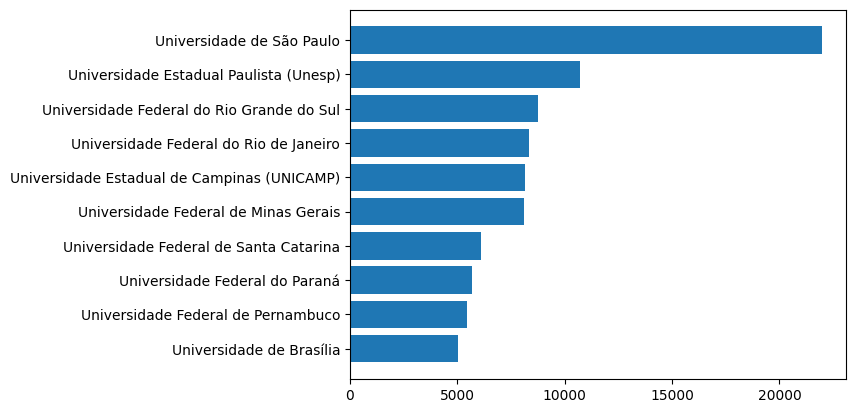

In [ ]:
import matplotlib.pyplot as plt
df_sorted = df.sort_values('net_mobility', ascending=True)
plt.barh(data=df_sorted, y='display_name', width='net_mobility')
plt.show()

In [ ]:
%%bigquery df --project=multiobs

SELECT *
FROM projectdb_mobility_br.institutions_net_mobility_all_years_areas_names
ORDER BY net_mobility DESC
LIMIT 100

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


- Agregar (nas autorias)> pessoa, instituticao ano
- Encontrar todas as instituicoes unicas para cada pessoa
- ENcontrar ano maximo e ano minimo de cada pessoa em cada instituicao
- Na ultima tabelas, somar entradas em cada ano, saídas em cada ano


In [ ]:
SELECT IDLattes, PrimeiraGrandeArea
FROM `multiobs.projectdb_lattes_2025.Tabelaconsolidadacomgeneroetitulacao`